# Unlocking Crime Trends

# Objective
Analyze crime trends, patterns, and factors to extract useful insight for various stakeholders (Law enforcement, policy makers, etc.)

## Use Cases: Crime Analysis
Identify crime trends, types, and victims demographics across different conditions, time periods, and locations.

## Key Questions:
What are the most common types of crimes?  
How do crime rates vary by time of day and location?  
Are there seasonal trends in crime?  

# Import libraries and load the data

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

from src.utils import *

np.random.seed(42)

In [46]:
df = pd.read_csv("data/Crime_Data_From_2020_to_Present_20250315.csv")

df.shape

(1005104, 28)

In [47]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,03/01/2020 12:00:00 AM,03/01/2020 12:00:00 AM,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,02/09/2020 12:00:00 AM,02/08/2020 12:00:00 AM,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 12:00:00 AM,11/04/2020 12:00:00 AM,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,05/10/2023 12:00:00 AM,03/10/2020 12:00:00 AM,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,09/09/2020 12:00:00 AM,09/09/2020 12:00:00 AM,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130


In [48]:
df.tail()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
1005099,250304184,02/18/2025 12:00:00 AM,02/14/2025 12:00:00 AM,1200,3,Southwest,328,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,700 W 28TH ST,NaN,34.0270,-118.2794
1005100,252104053,01/19/2025 12:00:00 AM,01/17/2025 12:00:00 AM,1530,21,Topanga,2114,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",...,IC,Invest Cont,341.0,NaN,NaN,NaN,22200 ELKWOOD ST,NaN,34.2128,-118.6103
1005101,250304214,02/23/2025 12:00:00 AM,02/21/2025 12:00:00 AM,1530,3,Southwest,358,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,3600 MCCLINTOCK AV,NaN,34.0212,-118.2895
1005102,250304203,02/20/2025 12:00:00 AM,02/13/2025 12:00:00 AM,2100,3,Southwest,325,1,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",...,IC,Invest Cont,522.0,NaN,NaN,NaN,2600 ELLENDALE PL,NaN,34.0307,-118.2923
1005103,250504051,01/14/2025 12:00:00 AM,01/14/2025 12:00:00 AM,1250,5,Harbor,509,1,210,ROBBERY,...,IC,Invest Cont,210.0,NaN,NaN,NaN,24300 WESTERN AV,NaN,33.8046,-118.3074


# Data Cleaning

## Check for missing data

In [49]:
print("Missing values in each column:")
df.isnull().sum()

Missing values in each column:


DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151724
Vict Age                0
Vict Sex           144751
Vict Descent       144763
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677860
Weapon Desc        677860
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           935958
Crm Cd 3          1002789
Crm Cd 4          1005040
LOCATION                0
Cross Street       850867
LAT                     0
LON                     0
dtype: int64

Most of the missing entries are in columns that are for crime codes or descriptions of crime aspects. Crime codes are used to identify or group aspects of the crime, and eliminating these columns would remove useful information about crime trends. Eliminating the columns related to descriptions may remove useful information about of the crime. I will keep all the missing data to retain the most information about the crimes.

## Check for duplicates

In [50]:
print("Duplicated entries in the dataset:", sum(df.duplicated()))

# Removing dr_no column because its not useful needed for analysis
df.drop(columns="DR_NO", inplace=True)

# Removing the "Crm Cd" column because it is the same as "Crm Cd 1"
df.drop(columns="Crm Cd 1", inplace=True)

# Removing crime codes 1, 2, and 3 because there is no description for them
# there is no way to know what they stand for
df.drop(columns=["Crm Cd 2", "Crm Cd 3", "Crm Cd 4"], inplace=True)

Duplicated entries in the dataset: 0


In [51]:
df.columns

Index(['Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME', 'Rpt Dist No',
       'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes', 'Vict Age', 'Vict Sex',
       'Vict Descent', 'Premis Cd', 'Premis Desc', 'Weapon Used Cd',
       'Weapon Desc', 'Status', 'Status Desc', 'LOCATION', 'Cross Street',
       'LAT', 'LON'],
      dtype='object')

In [52]:
new_cols = df.columns.to_series().str.lower().str.replace(" ", "_") \
    .str.replace("occ", "occurred") \
    .str.replace("rptd", "reported") \
    .str.replace("rpt", "reporting") \
    .str.replace("dist", "district") \
    .str.replace("vict", "victim") \
    .str.replace("premis", "premise") \
    .str.replace("crm", "crime") \
    .str.replace("cd", "code") \
    .str.replace("lat", "latitude") \
    .str.replace("lon", "longitude") \
    .str.replace("mocodes", "modus_operandi_codes") \
    .str.replace("part_1-2", "crime_class") \
        
for col in range(len(new_cols)):
    if new_cols.iloc[col] != df.columns[col]:
        print(f"{df.columns[col]} -> {new_cols.iloc[col]}")

df.columns = new_cols

Date Rptd -> date_reported
DATE OCC -> date_occurred
TIME OCC -> time_occurred
AREA -> area
AREA NAME -> area_name
Rpt Dist No -> reporting_district_no
Part 1-2 -> crime_class
Crm Cd -> crime_code
Crm Cd Desc -> crime_code_desc
Mocodes -> modus_operandi_codes
Vict Age -> victim_age
Vict Sex -> victim_sex
Vict Descent -> victim_descent
Premis Cd -> premise_code
Premis Desc -> premise_desc
Weapon Used Cd -> weapon_used_code
Weapon Desc -> weapon_desc
Status -> status
Status Desc -> status_desc
LOCATION -> location
Cross Street -> cross_street
LAT -> latitude
LON -> longitude


Renaming some of the columns to remove unnecessary abbreviations, also changed spaces to underscores.

## Standardize the data types

In [53]:
df = df.convert_dtypes()
df.dtypes

date_reported            string[python]
date_occurred            string[python]
time_occurred                     Int64
area                              Int64
area_name                string[python]
reporting_district_no             Int64
crime_class                       Int64
crime_code                        Int64
crime_code_desc          string[python]
modus_operandi_codes     string[python]
victim_age                        Int64
victim_sex               string[python]
victim_descent           string[python]
premise_code                      Int64
premise_desc             string[python]
weapon_used_code                  Int64
weapon_desc              string[python]
status                   string[python]
status_desc              string[python]
location                 string[python]
cross_street             string[python]
latitude                        Float64
longitude                       Float64
dtype: object

After using Pandas's function to correct data types, most columns have correct type. There are some outliers like dates that will need to be fixed manually.

In [54]:
categorical_cols = ["reporting_district_no", 
                    "victim_sex", 
                    "victim_descent",
                    "status", 
                    "weapon_used_code", 
                    "crime_code"]

[]

for col in categorical_cols:
    df[col] = df[col].astype("category")

These columns are categorical because there is no order. They are codes with meaning, not continuous values.

In [55]:
victim_sex_map = {
    "M": "Male",
    "F": "Female",
}

df["victim_sex"] = df["victim_sex"].map(victim_sex_map)
df.loc[df["victim_sex"].isnull(), "victim_sex"] = "Unknown"
df["victim_sex"] = df["victim_sex"].astype("category")

df["victim_sex"].head()

0       Male
1       Male
2    Unknown
3       Male
4    Unknown
Name: victim_sex, dtype: category
Categories (3, object): ['Female', 'Male', 'Unknown']

In [56]:
victim_desc_map = {
    "A": "Other Asian",
    "B": "Black",
    "C": "Chinese",
    "D": "Cambodian",
    "F": "Filipino",
    "G": "Guamanian",
    "H": "Hispanic",
    "I": "American Indian",
    "J": "Japanese",
    "K": "Korean",
    "L": "Laotian",
    "O": "Other",
    "P": "Pacific Islander",
    "S": "Samoan",
    "U": "Hawaiian",
    "V": "Vietnamese",
    "W": "White",
    "X": "Unknown",
    "Z": "Asian Indian"
}
 
df["victim_descent"] = df["victim_descent"].map(victim_desc_map).astype("category")

df["victim_descent"].head()

0      Other
1      Other
2    Unknown
3      Other
4        NaN
Name: victim_descent, dtype: category
Categories (19, object): ['American Indian', 'Asian Indian', 'Black', 'Cambodian', ..., 'Samoan', 'Unknown', 'Vietnamese', 'White']

In [57]:
df.select_dtypes(include=['string']).head()

,date_reported,date_occurred,area_name,crime_code_desc,modus_operandi_codes,premise_desc,weapon_desc,status_desc,location,cross_street
0,03/01/2020 12:00:00 AM,03/01/2020 12:00:00 AM,Wilshire,VEHICLE - STOLEN,<NA>,STREET,<NA>,Adult Arrest,1900 S LONGWOOD AV,<NA>
1,02/09/2020 12:00:00 AM,02/08/2020 12:00:00 AM,Central,BURGLARY FROM VEHICLE,1822 1402 0344,BUS STOP/LAYOVER (ALSO QUERY 124),<NA>,Invest Cont,1000 S FLOWER ST,<NA>
2,11/11/2020 12:00:00 AM,11/04/2020 12:00:00 AM,Southwest,BIKE - STOLEN,0344 1251,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",<NA>,Invest Cont,1400 W 37TH ST,<NA>
3,05/10/2023 12:00:00 AM,03/10/2020 12:00:00 AM,Van Nuys,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),0325 1501,CLOTHING STORE,<NA>,Invest Cont,14000 RIVERSIDE DR,<NA>
4,09/09/2020 12:00:00 AM,09/09/2020 12:00:00 AM,Hollenbeck,VEHICLE - STOLEN,<NA>,STREET,<NA>,Invest Cont,200 E AVENUE 28,<NA>


In [58]:
df["date_reported"] = pd.to_datetime(df["date_reported"], format="%m/%d/%Y %H:%M:%S %p")
df["date_occurred"] = pd.to_datetime(df["date_occurred"], format="%m/%d/%Y %I:%M:%S %p")

df.select_dtypes(include="datetime").head()

,date_reported,date_occurred
0,2020-03-01 12:00:00,2020-03-01
1,2020-02-09 12:00:00,2020-02-08
2,2020-11-11 12:00:00,2020-11-04
3,2023-05-10 12:00:00,2020-03-10
4,2020-09-09 12:00:00,2020-09-09


Converts string columns containing time stamps to datetime data type using Pandas's built-in functions.

Converts the Victim descent column into strings. This helps massively in understanding what the letters represented.

In [59]:
# Concatenating area name and number
area_info = df["area"].astype(str).str.cat(df["area_name"], sep="-")

df["area"] = area_info.astype("string")
df.drop("area_name", axis=1, inplace=True)

df["area"].dropna().head()

0      7-Wilshire
1       1-Central
2     3-Southwest
3      9-Van Nuys
4    4-Hollenbeck
Name: area, dtype: string

In [60]:
# Concatenating area crime code and crime code description
crime_info = df["crime_code"].astype(str).str.cat(df["crime_code_desc"], sep="-")

df["crime"] = crime_info.astype("string")
df.drop(["crime_code", "crime_code_desc"], axis=1, inplace=True)

df["crime"].dropna().head()

0                            510-VEHICLE - STOLEN
1                       330-BURGLARY FROM VEHICLE
2                               480-BIKE - STOLEN
3    343-SHOPLIFTING-GRAND THEFT ($950.01 & OVER)
4                            510-VEHICLE - STOLEN
Name: crime, dtype: string

In [61]:
# Concatenating area premise_code and premise_desc
premise_info = df["premise_code"].astype(str).str.cat(df["premise_desc"], sep="-")

df["premise"] = premise_info.astype("string")
df.drop(["premise_code", "premise_desc"], axis=1, inplace=True)

df["premise"].dropna().head()

0                                          101-STREET
1               128-BUS STOP/LAYOVER (ALSO QUERY 124)
2    502-MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)
3                                  405-CLOTHING STORE
4                                          101-STREET
Name: premise, dtype: string

This combines columns "area" and "area_name" into one. This reduces cardinality and simplifies the data.

In [62]:
# Concatenating area weapon_used_code and weapon_desc
weapon_info = df["weapon_used_code"].astype(str).str.cat(df["weapon_desc"], sep="-")

df["weapon"] = weapon_info.astype("string")
df.drop(["weapon_used_code", "weapon_desc"], axis=1, inplace=True)

df["weapon"].dropna().head()

44    400-STRONG-ARM (HANDS, FIST, FEET OR BODILY FO...
46                                    511-VERBAL THREAT
49         201-KNIFE WITH BLADE OVER 6 INCHES IN LENGTH
51    400-STRONG-ARM (HANDS, FIST, FEET OR BODILY FO...
55                      500-UNKNOWN WEAPON/OTHER WEAPON
Name: weapon, dtype: string

In [63]:
# Removing status column because status description is the same as status
df["status"] = df["status_desc"].astype("category")
df.drop(columns=["status_desc"], inplace=True)

df["status"].dropna().head()

0    Adult Arrest
1     Invest Cont
2     Invest Cont
3     Invest Cont
4     Invest Cont
Name: status, dtype: category
Categories (6, string): [Adult Arrest, Adult Other, Invest Cont, Juv Arrest, Juv Other, UNK]

In [64]:
df.select_dtypes(include=['number']).head()

,time_occurred,crime_class,victim_age,latitude,longitude
0,2130,1,0,34.0375,-118.3506
1,1800,1,47,34.0444,-118.2628
2,1700,1,19,34.021,-118.3002
3,2037,1,19,34.1576,-118.4387
4,630,1,0,34.082,-118.213


In [65]:
# Mapping crime_class 1->True, 2->False
df["crime_class"] = df["crime_class"].astype("object")
df["crime_class"].map({1: True, 2: False})
df["crime_class"] = df["crime_class"].astype("bool")

df.rename(columns={"crime_class": "violent_crime"}, inplace=True)
df["violent_crime"].head()

0    True
1    True
2    True
3    True
4    True
Name: violent_crime, dtype: bool

The old column "crime_class" was only used to differentiate between violent and non violent crimes. This correction will disambiguates the column, by renaming it and mapping numerical values to boolean values.

In [66]:
df["date_occurred"] = df["date_occurred"] + df["time_occurred"].apply(mil_time_to_timedelta)
df.drop(columns="time_occurred", inplace=True)

Simplifies "date_occurred" and "time_occurred" into one column.

# Distribution visualization

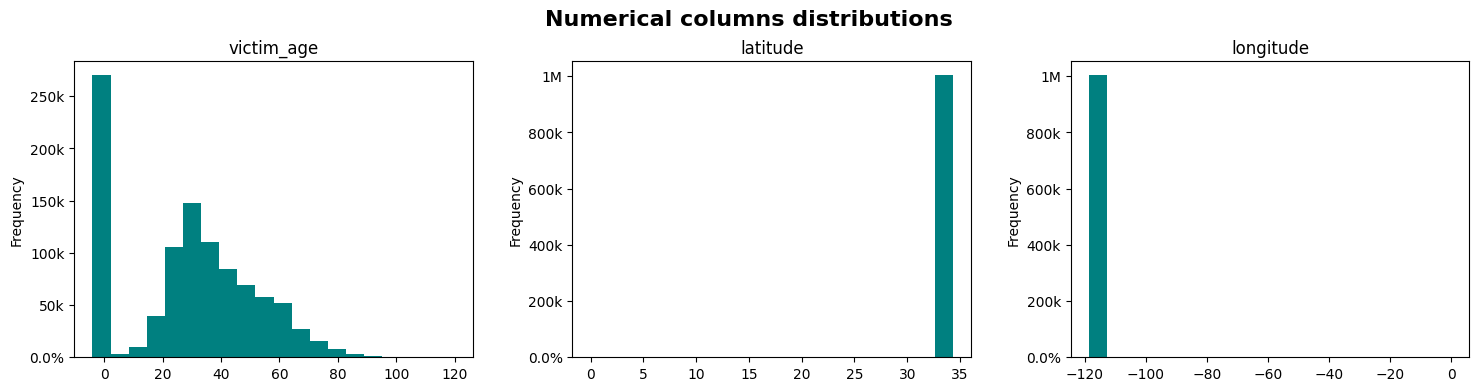

In [67]:
numerical_cols = df.select_dtypes(include="number").columns

fig, axs = plt.subplots(1, 3, figsize=(18, 4))
fig.subplots_adjust(wspace=0.25, top=0.85)
fig.suptitle("Numerical columns distributions", size=16, weight="bold")
        
for i, col in enumerate(numerical_cols):
    ax=axs[i]
    df[col].plot.hist(bins=20, ax=ax, color="teal")
    ax.set_title(col, size=12)
    
    ax.yaxis.set_major_formatter(number_formatter)
    
    
plt.show()

Visualization will start with numeric columns. The columns with codes are not present here because they are categorical data type. Column "dr_no" is an report identifier, it does not need to be visualized.

The victim age column looks like there are many of values that are 0, which is very unlikely. These are outliers and need to be corrected to correct the data histograms.

The latitude and longitude histograms look strange, there must be some values near 0 that are too low to be displayed by the histogram. If this is the case, then they too are outliers and need to be removed.

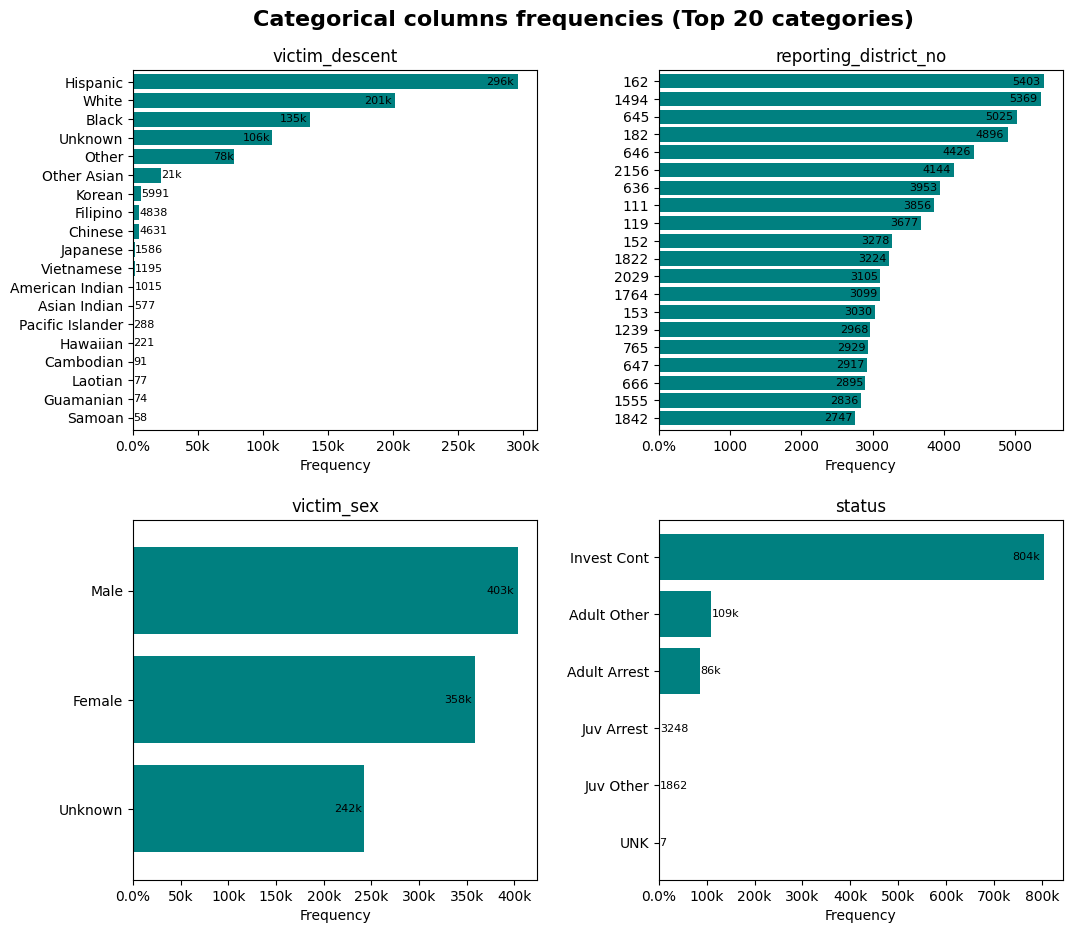

In [68]:
categorical_cols = df.select_dtypes(include="category").columns.to_list()

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Categorical columns frequencies (Top 20 categories)", size=16, weight="bold")
fig.subplots_adjust(wspace=0.3, hspace=0.25, top=0.92)

for i, col in enumerate(reorder_cols(categorical_cols, {0: "victim_descent", 2: "victim_sex"})):
    ax=axs[i//axs.shape[-1], i%axs.shape[-1]]
    
    val_counts = df[col].value_counts(ascending=False)[:20].sort_values()
    val_counts.index = val_counts.index.to_series().apply(lambda index: shorten_string(str(index), max_length=20))
    
    create_freq_barh(val_counts, ax)
    
plt.show()    

With most of them being codes for encoding information about the crime, there are over categories for most of these code columns. The exception is "vitim_age", "victim_sec", and "status" which have less categories. These columns contain use useful information about the victim and the status of the report.

For the column "victim_sex", a good portion of the values are unknown. The Unknown values are not set to Nan because its size is significant and it represents useful information in the analysis.

The "status" column has no relevance to the analysis in this report, therefore it will be removed for simplicity.

The columns "crime_code_1", "crime_code_2", "crime_code_3", and "crime_code_4" all have corollary columns that explain what each code means. Analyzing the data in these code columns is of limited use, without connecting the codes to their description, therefore I will use the use the descriptions from the corollary columns for my analysis.

The column "reporting_district_no" has no corollary column to explain what each code means. For this reason, it may prove difficult to gain useful information out of it.

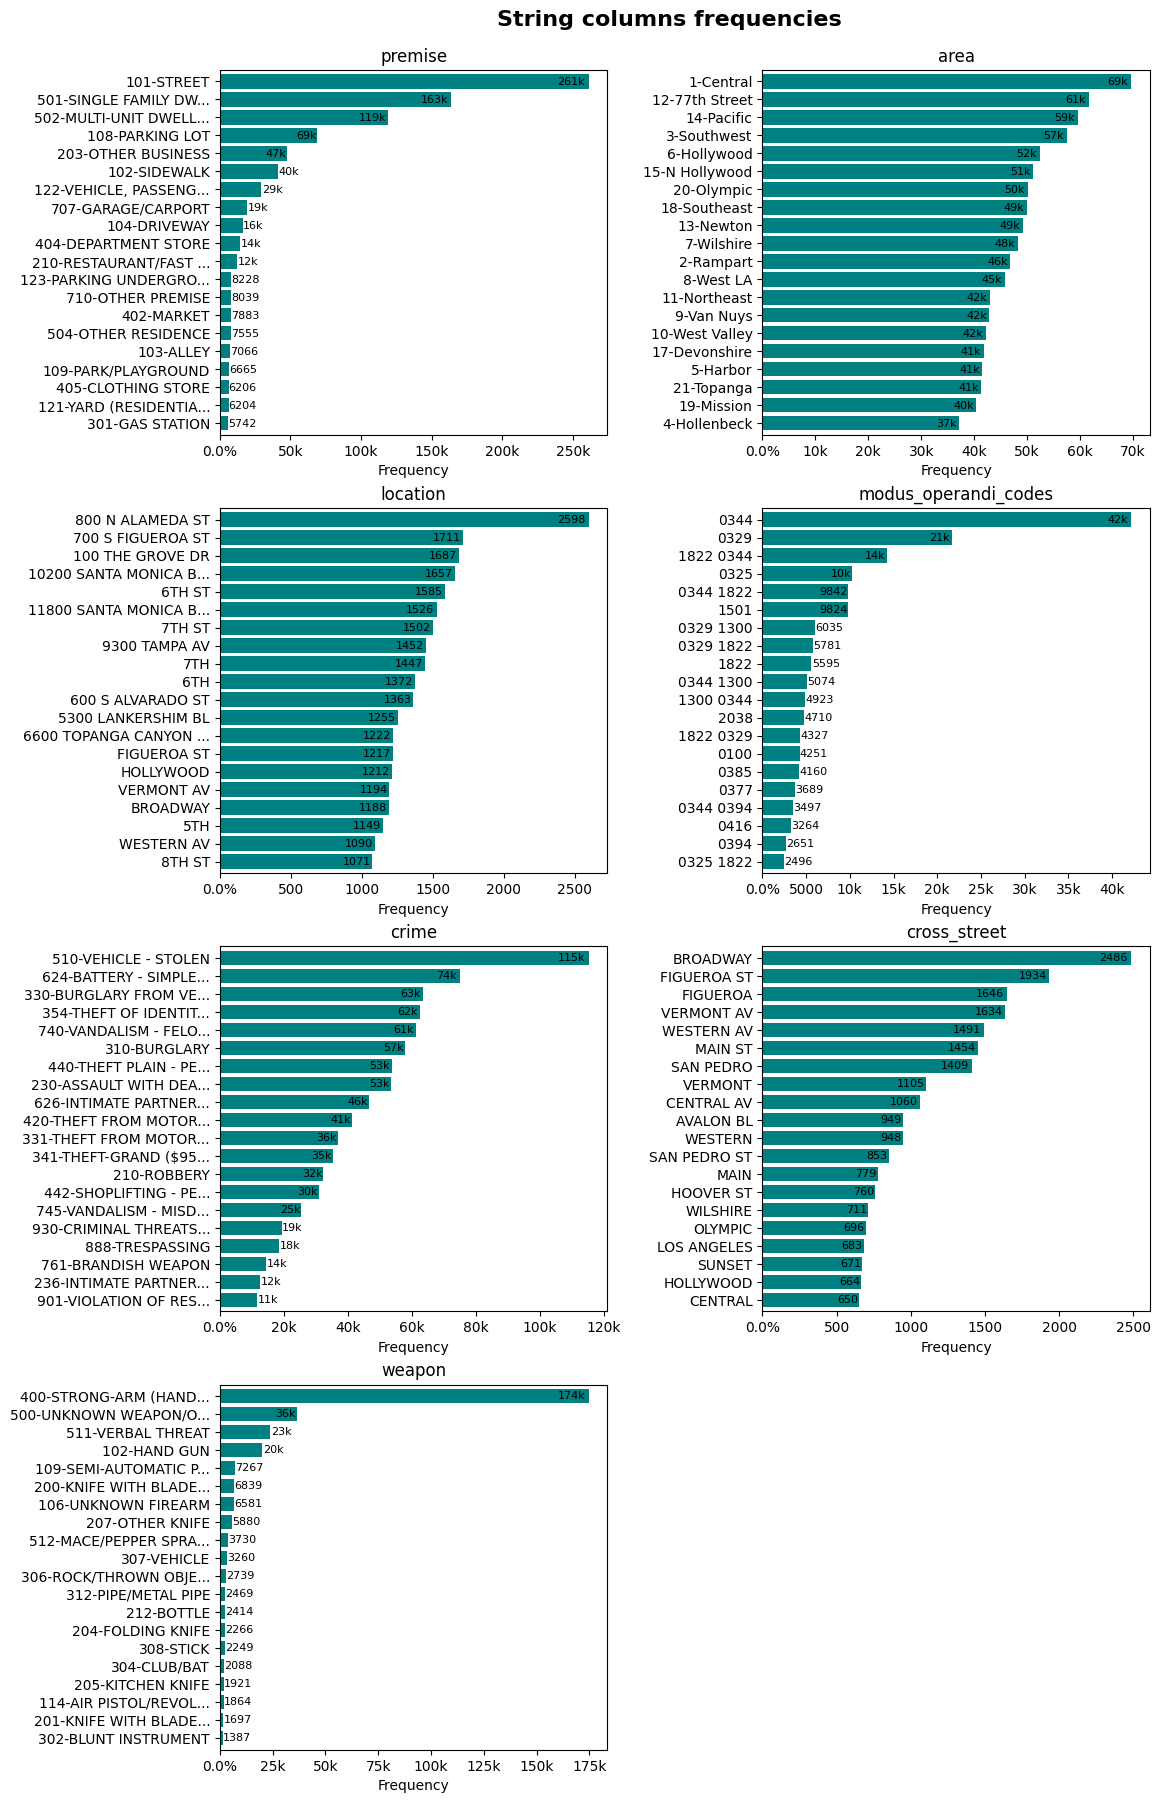

In [80]:
string_cols = df.select_dtypes(include=['string']).columns.to_list()

fig, axs = plt.subplots(4, 2, figsize=(12, 20))
fig.suptitle("String columns frequencies", size=16, weight="bold")
fig.subplots_adjust(wspace=0.40, top=0.95)

for i, col in enumerate(reorder_cols(string_cols, {0: "premise", 2: "location", 4: "crime"})):
    ax=axs[i//axs.shape[-1], i%axs.shape[-1]]
    
    val_counts = df[col].value_counts(ascending=False)[:20].sort_values()
    val_counts.index = val_counts.index.str.replace(r"(\s+)", " ", regex=True)
    val_counts.index = val_counts.index.to_series().apply(lambda index: shorten_string(index, max_length=20))
    
    create_freq_barh(val_counts, ax)
    
fig.delaxes(axs[3, 1])
    
plt.show()


Columns "crime_code_desc" and "location" will need to processing to remove some unnecessary parts of the strings. They both have extra spaces, which need to be reduced into one space.

For column "modus_operandi_codes", the codes need to be separated by spaces and then look at the frequencies of each individual code along with any relationships between them.

The columns "premise" and "weapon" were all created by combining a code and the description from the raw data. 

For column "cross_street", the names need to be checked for missing street suffixes. There are some cross streets, like "Main", missing suffixes. Fixing this error will give a correct distribution of cross streets. 

# Refining the data

In [ ]:
# Removes invalid ages (<=0)
df.loc[df["victim_age"] <= 0, "victim_age"] = np.nan

# Removes invalid coordinates (=0)
df.loc[df["latitude"] == 0, "latitude"] = np.nan
df.loc[df["longitude"] == 0, "longitude"] = np.nan

This will remove some of the outliers in those columns. This way the analysis can focus on the correct range of possible values.

In [ ]:
# The status of the report is irrelevant, so we drop it
df.drop(columns="status", inplace=True)

# The reporting district has no corollary columns to define the meaning of the codes, so we drop it
df.drop(columns="reporting_district_no", inplace=True)

The "status" column was removed because it does not provide useful information for our analysis.

The "reporting_district_no" was removed because there is no table to understand what the values mean, therefore its hard to analyze/visualize the meaning.

In [ ]:
# Removes extra spaces from strings
df["location"] = df["location"].replace(r"(\s+)", " ", regex=True)
df["cross_street"] = df["cross_street"].replace(r"(\s+)", " ", regex=True)

These columns have some extra spaces, this will remove it and make sure its always just 1 space.

In [ ]:
additional_info_pat = r"(\s\(.*\))"

df["additional_crime_info"] = df["crime"].str.extract(additional_info_pat)[0].str[2:-1]
df["crime"] = df["crime"].str.replace(additional_info_pat, "", regex=True).replace(r"(\s+)", " ", regex=True)

df["additional_weapon_info"] = df["weapon"].str.extract(additional_info_pat)[0].str[2:-1]
df["weapon"] = df["weapon"].str.replace(additional_info_pat, "", regex=True).replace(r"(\s+)", " ", regex=True)

df["additional_premise_info"] = df["premise"].str.extract(additional_info_pat)[0].str[2:-1]
df["premise"] = df["premise"].str.replace(additional_info_pat, "", regex=True).replace(r"(\s+)", " ", regex=True)

# Exploratory Data visualization

### Crime Type Frequency

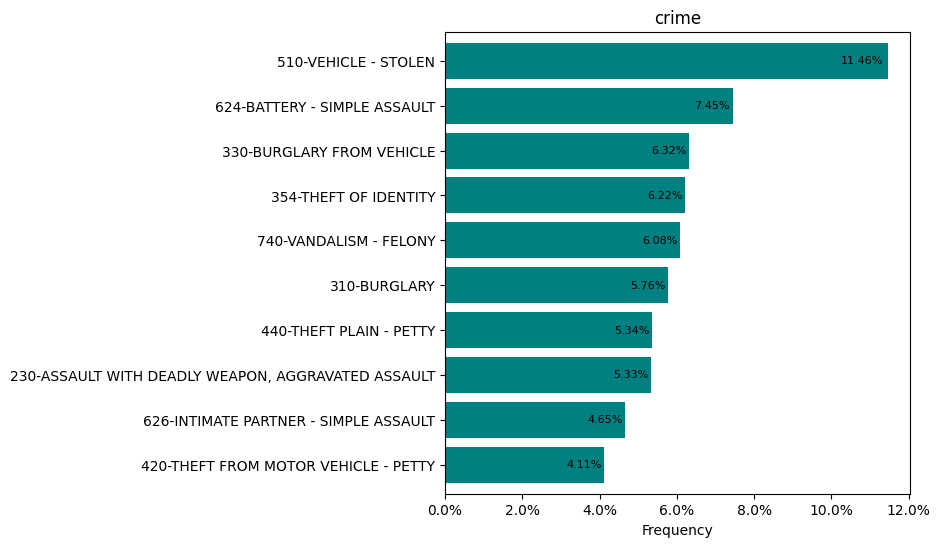

In [ ]:
create_freq_barh(df["crime"].value_counts(normalize=True, ascending=True)[-10:])

**Observation:** Theft and Assault account for multiple crimes in the top 10. Vehicular theft is the most common by far, almost twice as common as second place.  

**Theft**: Stolen Vehicle, Burglary from Vehicle, Theft of Identity, Burglary, petty theft, and theft from motor vehicle.  
**Assault**: Simple assault - Battery, Assault with a deadly weapon, and assault on intimate partner. 

### Crime weapon type Frequency

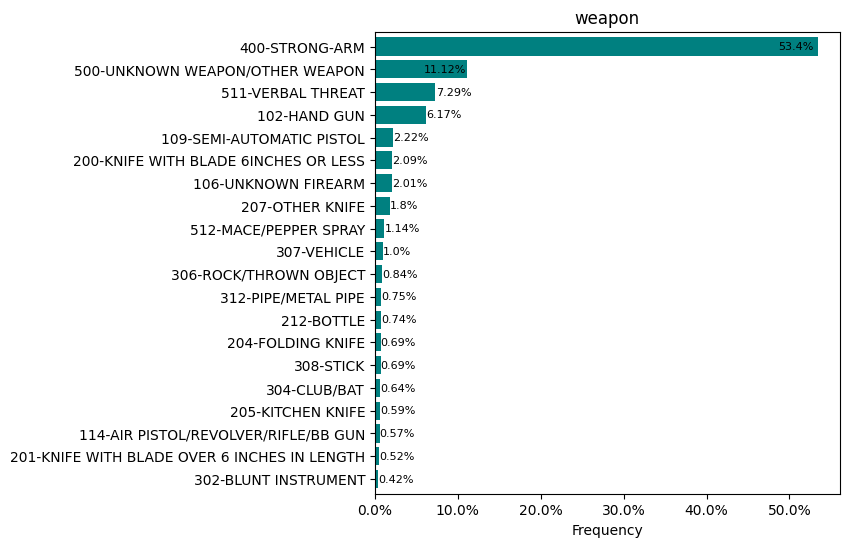

In [ ]:
create_freq_barh(df["weapon"].value_counts(normalize=True, ascending=True)[-20:])

**Observation:** Over half of all weapons in crimes is with the use of bodily force. With only 6.17% being with a handgun.

### Crime premise type Frequency

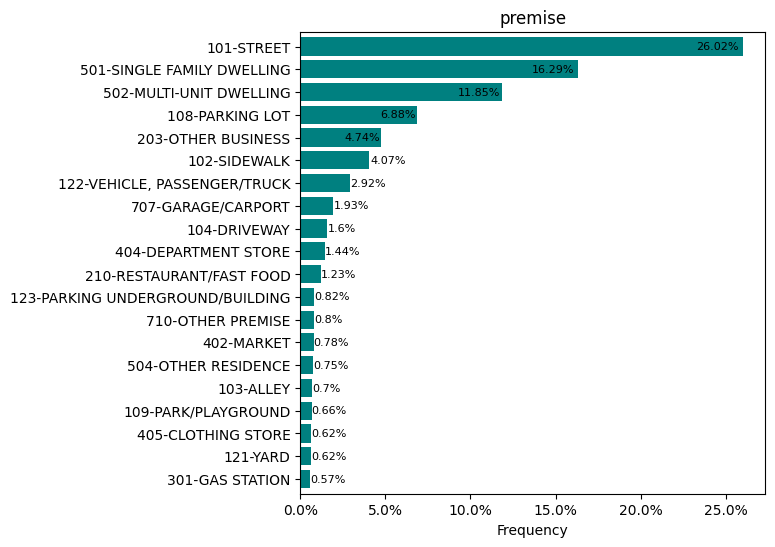

In [ ]:
create_freq_barh(df["premise"].value_counts(normalize=True, ascending=True)[-20:])

**Observation:** The location of most crimes is either outside (street or parking lot) or inside the dwelling (Single-family or multi-family).

### Crime frequency by hour of the day

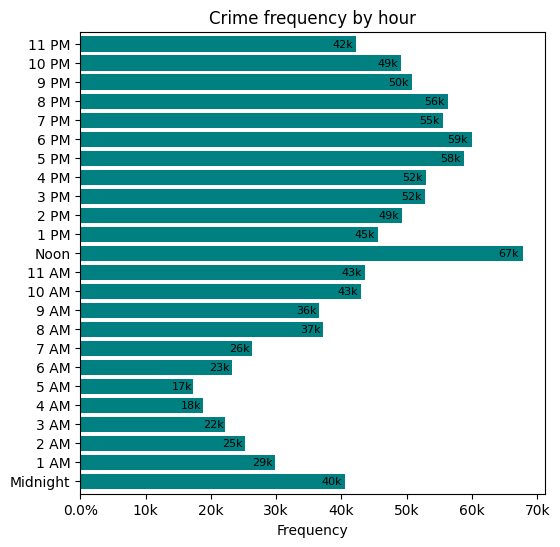

In [ ]:
df_display = df.copy()
df_display["hour_occurred"] = df_display["date_occurred"].dt.hour
crime_per_hour = df_display.groupby("hour_occurred")["crime"].agg("count")
crime_per_hour.index = crime_per_hour.index.to_series().apply(hour_num_conv)
crime_per_hour.index.name = "Crime frequency by hour"

create_freq_barh(crime_per_hour)

**Observation:** Crime is most common in the afternoon. This shows criminals are not afraid to commit crimes in broad daylight.

### Crime frequency by month

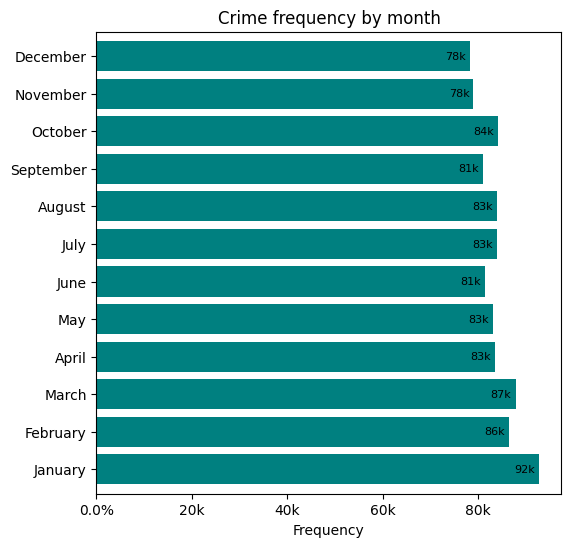

In [ ]:
df_display = df.copy()
df_display["hour_occurred"] = df_display["date_occurred"].dt.month
crime_per_month = df_display.groupby("hour_occurred")["crime"].agg("count")
crime_per_month.index = crime_per_month.index.to_series().apply(month_conv)
crime_per_month.index.name = "Crime frequency by month"

create_freq_barh(crime_per_month)

**Observation** Crime frequencies appear to be consistent across months with no strong season pattern detected.

### Crime frequency by day of the week

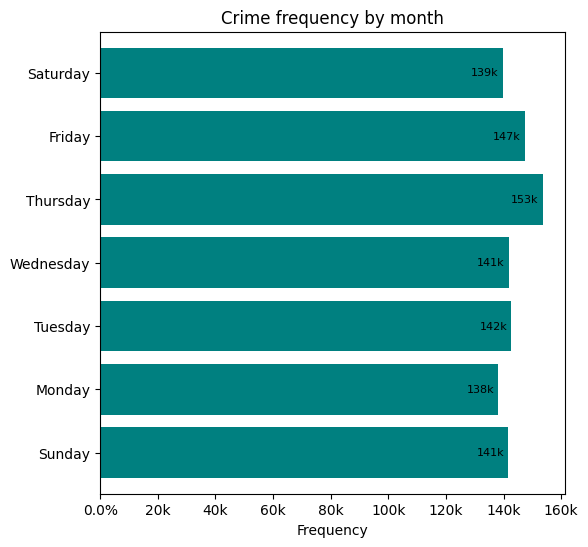

In [ ]:
df_display = df.copy()
df_display["hour_occurred"] = df_display["date_occurred"].dt.day_of_week
crime_per_day = df_display.groupby("hour_occurred")["crime"].agg("count")
crime_per_day.index = crime_per_day.index.to_series().apply(day_of_week_conv)
crime_per_day.index.name = "Crime frequency by month"

create_freq_barh(crime_per_day)

**Observation** Crime frequencies appear to be consistent across the days of the week with no strong weekly weekly pattern detected.

### Crime Frequency by Hour of Day – Top 5 Crimes

[]

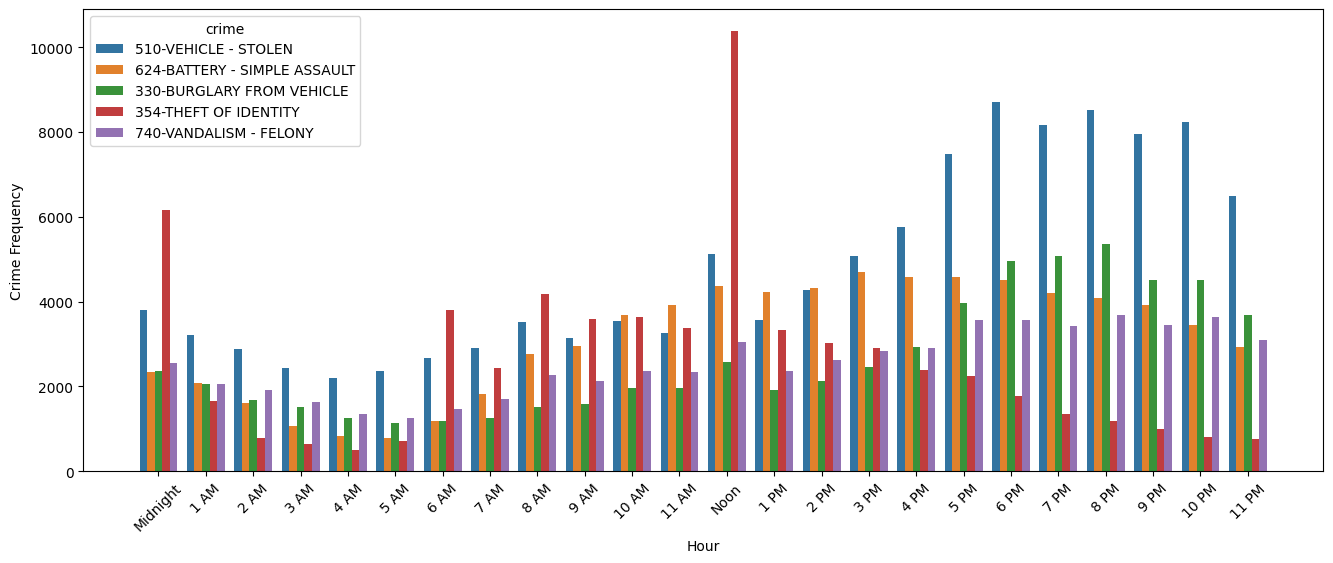

In [ ]:
top_5_crimes = df["crime"].value_counts(ascending=False)[:5].index.to_series().reset_index(drop=True)


df_display = df[df["crime"].isin(top_5_crimes)].copy()
df_display["hour_occurred"] = df_display["date_occurred"].dt.hour
crime_per_hour = df_display.groupby(["hour_occurred", "crime"]).agg({"date_occurred": "count"}).reset_index()
crime_per_hour["crime_order"] = crime_per_hour["crime"].apply(lambda row: top_5_crimes[top_5_crimes == row].index.values[0])
crime_per_hour.sort_values(by=["crime_order", "hour_occurred"], inplace=True)

crime_per_hour["hour_occurred"] = crime_per_hour["hour_occurred"].apply(hour_num_conv)

fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(crime_per_hour, x="hour_occurred", y="date_occurred", hue="crime", ax=ax)
plt.ylabel("Crime Frequency")
plt.xlabel("Hour")
plt.xticks(rotation=45)
plt.plot()



**Observations:** 
- <span style="color:#3274a1;">Vehicle Theft</span>: peaks in the late afternoon and evening, especially between 5 PM and 9 PM.
- <span style="color:#e1812c;">Battery</span>: is more common from mid-morning to early evening.
- <span style="color:#3a923a;">Burglary from vehicle</span>: rise in the evening hours.
- <span style="color:#c03d3e;">Identity Theft</span>: Shows an unusual spike at exactly midnight and noon, this is likely due to entry defaults rather than real-world crime activity.
- <span style="color:#9372b2;">Felony vandalism</span>: also rise in the evening hours.

### Crime Density Map

In [ ]:
df_display = df.copy()
df_display["area_no"] = df_display["area"].str.split("-").str[0].astype(int)
df_display.sort_values("area_no", inplace=True)

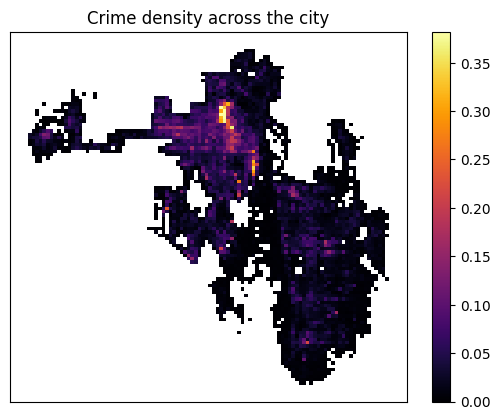

In [ ]:
sns.histplot(df_display, x="latitude", y="longitude", stat="percent", cbar=True, cmap="inferno", bins=100, pmax=0.975)
plt.tick_params(
    axis='both',
    which='both',
    bottom=False,
    left=False,
    labelleft=False,
    labelbottom=False) # labels along the bottom edge are off

plt.xlabel("")
plt.ylabel("")
plt.title("Crime density across the city")
plt.show()

**Observation**: Notable hotspots appear in the downtown and central-west regions, suggesting these may be priority areas for enforcement or further analysis.

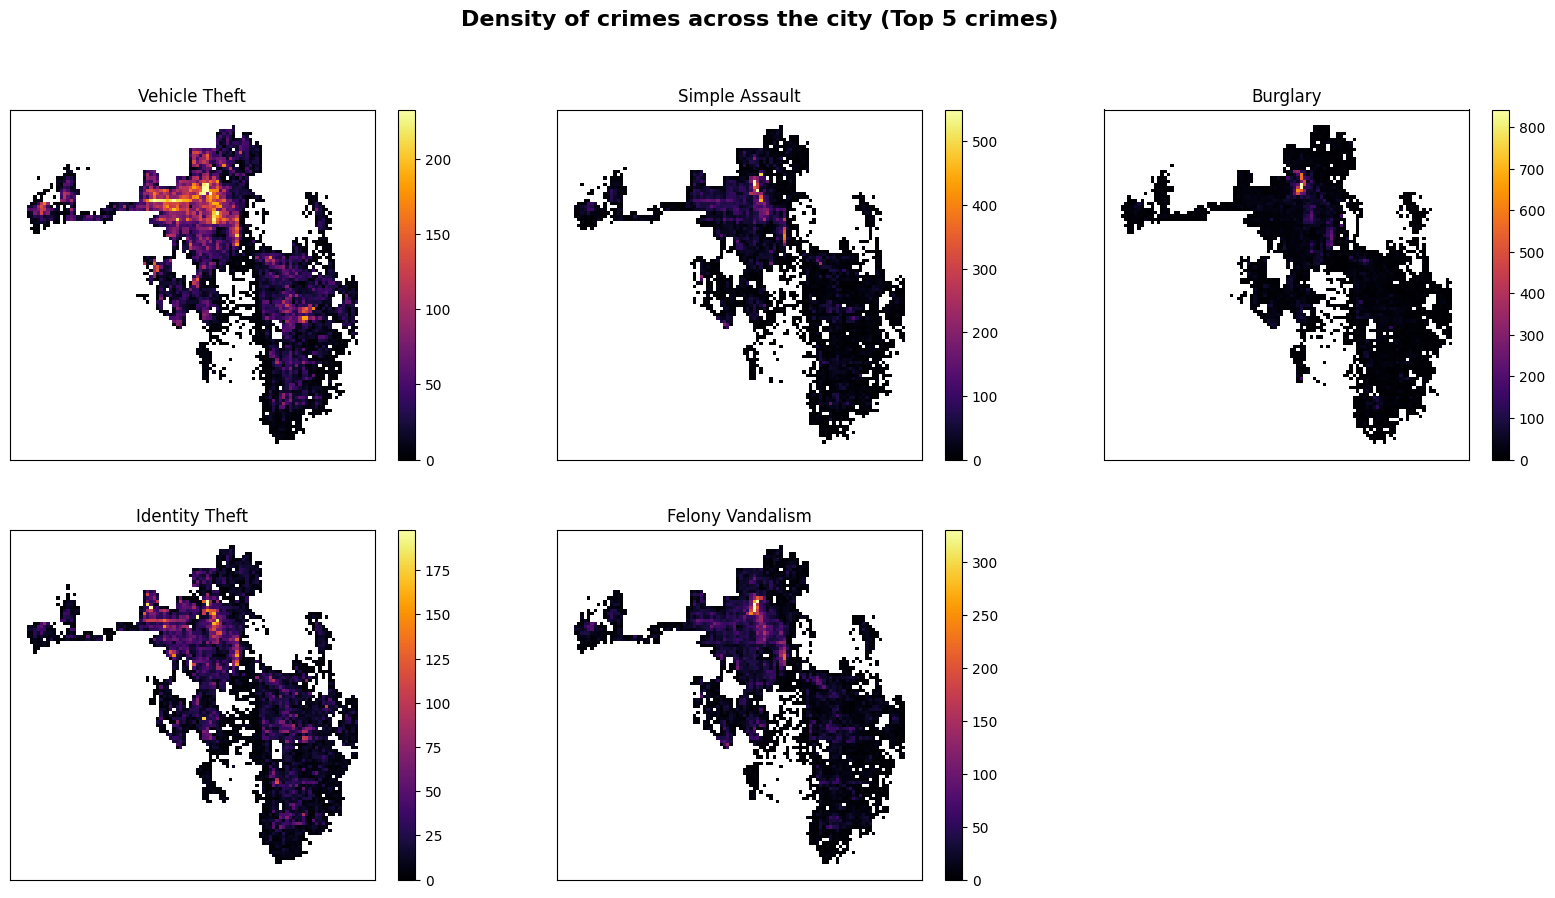

In [ ]:
top_crime_desc = pd.Series(["Vehicle Theft", "Simple Assault", "Burglary", "Identity Theft", "Felony Vandalism"])

fig, axs = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle("Density of crimes across the city (Top 5 crimes)", size=16, weight="bold")
for i, crime in enumerate(top_5_crimes):
    ax = axs[i//axs.shape[-1], i%axs.shape[-1]]
    sns.histplot(df_display[df_display["crime"] == crime], x="latitude", y="longitude", stat="count", 
                 cbar=True, cmap="inferno", bins=100, pmax=0.975, ax=ax)
    ax.tick_params(
        axis='both',
        which='both',
        bottom=False,
        left=False,
        labelleft=False,
        labelbottom=False)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(top_crime_desc[i])

fig.delaxes(axs[1, 2])
plt.show()

**Observations**
- Vehicle Theft and Identity Theft: are widespread, with consistent hotspots in the center-west of the map.
- Simple Assault and Felony Vandalism: appear to be more concentrated in specific areas.
- Burglary: shows a very tight cluster, suggest highly localized pattern in the top-center of the map.